In [9]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
dir = os.getcwd()
DATA_DIR = dir + '/data/transcript_6'

In [5]:
from unity_utils import UnityTranslator
from nlp_utils import *

demo = UnityTranslator.get_from(DATA_DIR)
keyframes = get_imi_dir(f'{DATA_DIR}/keyframes')


fps: 60.0
frame_interval: 30
new_width 540, new_height: 960
Stored 32 frames.
total_tokens: 1987832
processed data in subdir: /Users/edward_kim/Desktop/narrated_demo/v2/data/transcript_6/demonstration0
fps: 60.0
frame_interval: 30
new_width 540, new_height: 960
Stored 47 frames.
total_tokens: 3075955
processed data in subdir: /Users/edward_kim/Desktop/narrated_demo/v2/data/transcript_6/demonstration1


In [6]:
import json

## TODO: need to input a list of actions as well. 

inference_instructions = """
You are given a recording of an expert, or a coach, demonstrating how to do a certain physical task. 
The recordings consist of (1) a video, and (2) a transcription of the video. 
The video shows a physical demonstration of the task by the expert. 
The the transcription of the video consists of the expert's explanation as the expert physically demonstrates the task. 

You need to analyze the task, identify what subtasks of the expert it consists of, and output the subtask structure as a 
directed graph in a json file. Note that this subtask structure ONLY represents the subtasks that the expert needs to do, not others. 

A node in the graph represents a subtask which consists of (1) what action the expert takes, (2) description of the action, 
(3) termination condition for the subtask to complete, and (4) a unique integer identification number of the node. 
The set of nodes are given as a list where the order of the nodes indicate the chronological order in which subtasks occur 
in the expert's demonstration. So, the order of the nodes is important. 

An edge of the graph points is a directed arrow pointing from one node to another node. 
An edge consists of (1) the unique integer identification numbers of the node it is pointing from and to, 
(2) precondition, i.e. a boolean condition for transitioning to a subtask from another subtask, and
(3) its own unique identification number. 

This directed graph is encoded as a json file of the following format.

{
    'nodes': [
        {
            'id': int,  // Unique identifier for the task node
            'action': str,  // can be either 'wait', 'move_to', or 'pass'
            'info': str,  // Description of the action
            'termination': str,  // Condition under which the subtask terminates
            'keyframe': int, // index of the frame in which the termination condition is satisfied
        }
    ],
    "edges": [
        {
            'id': int,  // Unique identifier for the condition edge
            'from': int,  // ID of the previous node
            'to': int,  // ID of the next node
            'precondition': str,  // Condition under which the transition happens
            'keyframe': int, // index of the frame in which the precondition is satisfied
        }
    ]
}

Please output a json file encoding the directed graph. 
If the provided directed graph is empty, then please create the json from scratch. 

Note that this subtask structure ONLY represents the subtasks that the expert needs to do.
It MUST NOT contain any subtasks of others in the video. 
If there is no precondition or termination condition, state 'None.'

"""

entries = [
    Chat.Entry(role='system', text=inference_instructions),
    Chat.Entry(role='user', text=f'Here is a transcription: {demo.language}')
] + [Chat.Entry(role='user', text=f'Frame index: {idx}', im=get_im(im_dir)) for idx, im_dir in enumerate(keyframes)]
chat = Chat(client, model='o3-mini')
response = json.loads(chat(entries, json=True))
print('Inference done.')

AttributeError: 'list' object has no attribute 'language'

In [ ]:
with open('fsm.json', 'w') as f:
    f.write(response)

In [13]:
print(response['nodes'])
print(response['edges'])

[{'id': 0, 'action': 'move_to', 'info': 'Get possession of the ball.', 'termination': 'Ball is in possession.', 'keyframe': 1}, {'id': 1, 'action': 'pass', 'info': 'Pass the ball to your teammate.', 'termination': 'Ball is with teammate.', 'keyframe': 2}, {'id': 2, 'action': 'wait', 'info': 'Wait for teammate to return the ball.', 'termination': 'Teammate returns the ball.', 'keyframe': 4}, {'id': 3, 'action': 'pass', 'info': 'Pass the ball to teammate once they breach the enemy line.', 'termination': 'Ball is passed to teammate behind enemy line.', 'keyframe': 9}]
[{'id': 0, 'from': 0, 'to': 1, 'precondition': 'Ball is in possession.', 'keyframe': 1}, {'id': 1, 'from': 1, 'to': 2, 'precondition': 'Ball is with teammate.', 'keyframe': 2}, {'id': 2, 'from': 2, 'to': 3, 'precondition': 'Teammate returns the ball.', 'keyframe': 5}]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


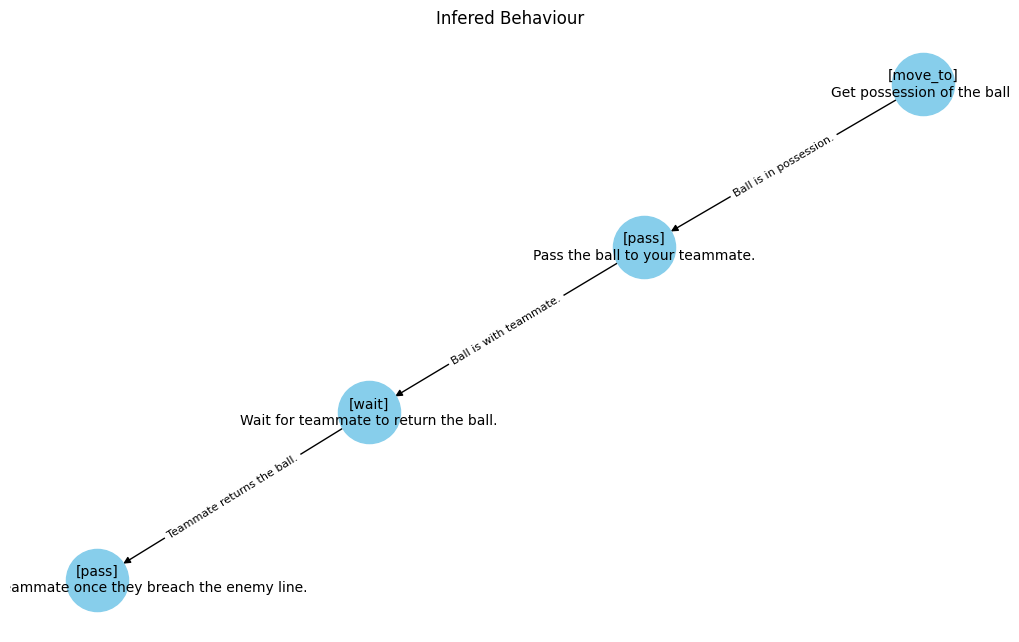

In [14]:
%load_ext autoreload
%autoreload 2

from synth_utils import Act
from scenic_fc.api import api

act = Act.from_dict(response, api)
act.show()

In [15]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image

# TODO: Also, need to ask about the preconditions

modifications = []
for i, t in enumerate(act.nodes):

    print(f'{i + 1}/{len(act.nodes)}')
    print(t)
    print('Termination:', t.termination.info)
    print('Infered keyframe:', t.keyframe)
    
    plt.imshow(Image.open(keyframes[t.keyframe]))
    plt.axis('off')
    plt.show()

    manual_keyframe = input('Type the index (0-indexed) of keyframe to modify it or return to continue.')
    if manual_keyframe != '' and int(manual_keyframe) < len(keyframes):
        t.keyframe = manual_keyframe
        modifications += [f'[Task {i + 1}] Modified keyframe: {t.original.keyframe} -> {t.keyframe}']

    clear_output(wait=False)

if not len(modifications):
    print('No modifications.')
for mod in modifications:
    print(mod)

[Task 1] Modified keyframe: 1 -> 0


In [31]:
%load_ext autoreload
%autoreload 2

from synth_utils import Synth

pipe = Synth(act, demo, api)
pipe.run()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
MOVETO SYNTH
PASS SYNTH
WAIT SYNTH
PASS SYNTH


In [32]:
%load_ext autoreload
%autoreload 2

program = pipe.to_dict()
print(json.dumps(program, indent=4))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{
    "nodes": [
        {
            "id": 0,
            "action": "move_to",
            "target": {
                "logic": "A",
                "map": [
                    "A"
                ],
                "constraints": [
                    {
                        "id": "A",
                        "constraint": "has_ball_possession",
                        "args": {
                            "ref": "user_player_id"
                        }
                    }
                ]
            },
            "termination": {
                "logic": "AND",
                "map": [
                    "has_ball_possession_player2",
                    "has_ball_possession_player1"
                ],
                "constraints": [
                    {
                        "id": "has_ball_possession_player1",
                        "constraint": "has_ball_possession",
        

[move_to] Get possession of the ball.
